# Optimal Market Making with Avellaneda-Stoikov Inventory Control

---

***Abstract:*** This project implements the Avellaneda-Stoikov framework for optimal market making in a high-volume equity environment. The objective is to manage the fundamental trade-off between spread capture and inventory risk by using Maximum Likelihood Estimation (MLE) to calibrate order-arrival intensities and applying stochastic control theory. The engine dynamically adjusts bid-ask quotes relative to a calculated indifference price.

***Key learnings:*** Throughout this project, I developed a deep understanding of market microstructure, specifically how liquidity decay ($k$) and risk aversion ($\gamma$) dictate optimal quoting behavior. I also gained proficiency in event-driven backtesting and quantitative P&L attribution.

***Discoveries:*** The simulation results demonstrate that the Avellaneda-Stoikov strategy significantly reduces inventory variance relative to the symmetric "naive" quoting strategy. The model successfully mitigates Adverse Selection by shading quotes as inventory accumulates, resulting in a more stable Sharpe Ratio in volatile market regimes.

If you are interested in the code, skip to Section 2.

This notebook is constructed as follows.

---

## 1. Problem Statement and Strategy Objectives

### 1.1. A Brief Overview of Market Making

In their paper published in 2006 [[1]](#references), they addressed two main concerns for market makers, which quote 

> *"(i) The agent faces an **inventory risk** due to the diffusive nature of the stock's mid-price and (ii) a **transactions risk** due to a Poisson arrival of market buy and sell orders."*, 

and proposed a two-step procedure to tackle these. However, before we move to further complex maths, let us take a step back and understand the problem. A good way to understand it is to consider the following analogy. Imagine you run a grocery store that buys and sells apples, and you post these two prices on your board: "We buy apples at $\$0.98$," and "We sell apples at $\$1.02$." The gap between the two prices, or bid-ask spread, is your profit. Then, you see, you want the gap to be as wide as possible so that you can earn more, but by lowering the buying price and increasing the selling price, no one will buy or sell you apples. On a contrary, if the spread is thin, there is a chance that a more professional wholesaler, who has better information than you, will only trade with you when they know the town price is about to move — selling you apples right before prices fall or buying from you right before prices rise. In other words, informed traders use the market maker's limit orders as a 'liquidity backstop' to offload their own risk—a phenomenon known as Adverse Selection. Okay, so that is market making, at least that is to my understanding.

Now, we consider a few problems of market making, mentioned by Avellaneda and Stoikov:

1. **Inventory risk.** Suppose that one day, several farmers are showing up in the town, selling you apples, and you decide to restock 5,000 of them. However, the news soon spreads that there has just been a new wave of apple supply to the town. So, the fair price drops from $\$1.00$ to $\$0.90$. There you go, the more inventory that you have, the more exposed you are to the fluctuation of the market.
2. **Transactions risk.** Well, since you cannot control the flow of customers or farmers (i.e., the demand and supply), at some point, either you suddenly have more apples than you should have, or you are short of stock. Because of this randomness, even if prices never changed, unpredictable order arrivals can push you into dangerous inventory imbalances.

### 1.2. The Avellaneda-Stoikov's Inventory-Optimized Market Making Framework

To deal with these two risks, we need to do two things. First, calculate the *reservation (or, indifference) price* of the asset.

$$
r(S,q,t)=S−q\gamma\sigma^2(T−t)\text{, where }\begin{cases}
S\text{ is the current (market) mid-price}\\
q\text{ is the inventory of the agent}\\
\gamma\text{ is the risk aversion}\\
\sigma\text{ is the volatility}\\
(T-t)\text{ is the time remaining}
\end{cases}
$$

The outcome is the price, accounting for current inventory risks. The adjustment to the market mid-price comes from $-q\gamma\sigma^2(T−t)$. The intuition is that if $(q>0)$, we are in a long position, and the subtraction is crucial because it pushes the reservation price down. It shows other participants your willingness to sell our excess inventory. On the other hand, when $(q<0)$ (i.e., selling short), the equation ensures that we increase the price to buy back the short position. Now, the Greeks. $\gamma$ allows you to control the level of reaction to holding a position. Simply put, the higher $\gamma$ is, the more strongly you will react to changes of your position; even a small market movement will make you adjust your price a lot to get back to neutral. $\sigma^2$ is the market’s variance. It measures how uncertain future prices are, so higher volatility increases the risk of holding inventory and therefore enlarges the reservation price shift proportionally.

Second, we calibrate our bid-ask positions around the reservation price $(r)$ with a distance $\frac{\Delta}{2}$. That brings us to the Optimal Spread equation:

$$
\Delta=\delta^a+\delta^b=\gamma\sigma^2(T-t)+\frac{2}{\gamma}\ln\left(1+\frac{\gamma}{k}\right)
$$

where

$$
\begin{cases}
\gamma\sigma^2(T-t)\text{ is the Inventory Risk Component, and}\\[1em]
\dfrac{2}{\gamma}\ln\left(1+\dfrac{\gamma}{k}\right)\text{ is the Order Flow Component}
\end{cases}
$$

The execution prices will simply be

- Bid Price $= r - \frac{\Delta}{2}$
- Ask Price $= r + \frac{\Delta}{2}$

## 2. Implementation of The Avellaneda-Stoikov Framework

In [1]:
import numpy as np
import pandas as pd

class AvellanedaStoikovEngine:
    """
    Core implementation of the Avellaneda-Stoikov (2008) Market Making Model.
    Focuses on the calculation of the Reservation Price and the Optimal Spreads 
    using vectorized NumPy operations for high-performance benchmarks.
    """
    def __init__(self, gamma=0.01, k=1.5, A=140.0, sigma=2.0):
        self.gamma = gamma  # Risk aversion parameter
        self.k = k          # Order book depth (liquidity decay)
        self.A = A          # Arrival intensity of market orders
        self.sigma = sigma  # Price volatility (standard deviation)

    def calculate_reservation_price(self, s, q, t, T):
        """
        Calculates r(s, q, t): The price at which the MM is indifferent 
        to their current inventory risk.
        
        Equation: r = s - q * gamma * sigma^2 * (T - t)
        """
        time_remaining = T - t
        return s - (q * self.gamma * (self.sigma**2) * time_remaining)

    def calculate_optimal_spread(self, t, T):
        """
        Calculates the symmetric spread around the reservation price.
        
        Equation: delta_bid + delta_ask = gamma * sigma^2 * (T - t) + (2/gamma) * ln(1 + gamma/k)
        """
        time_remaining = T - t
        first_term = self.gamma * (self.sigma**2) * time_remaining
        second_term = (2 / self.gamma) * np.log(1 + (self.gamma / self.k))
        return first_term + second_term

    def compute_quotes(self, mid_prices, inventory, time_steps, total_time):
        """
        Vectorized computation of optimal Bid and Ask prices across a time series.
        
        Parameters:
        mid_prices (np.array): Market mid-prices (s)
        inventory (np.array): Current inventory levels (q)
        time_steps (np.array): Current time indices (t)
        total_time (float): Horizon (T)
        """
        # Ensure inputs are numpy arrays for vectorization
        s = np.array(mid_prices)
        q = np.array(inventory)
        t = np.array(time_steps)
        T = total_time
        
        # Calculate Reservation Price (r)
        res_prices = self.calculate_reservation_price(s, q, t, T)
        
        # Calculate Half-Spread (delta)
        total_spreads = self.calculate_optimal_spread(t, T)
        half_spreads = total_spreads / 2
        
        # Determine Final Quotes
        bid_quotes = res_prices - half_spreads
        ask_quotes = res_prices + half_spreads
        
        return pd.DataFrame({
            'mid_price': s,
            'reservation_price': res_prices,
            'optimal_bid': bid_quotes,
            'optimal_ask': ask_quotes,
            'spread': total_spreads
        })

    def get_fill_probabilities(self, delta):
        """
        Calculates the probability of an order being filled given its depth. It
        follows the Poisson distribution rate.
        
        Equation: Pr(fill) = A * exp(-k * delta)
        """
        return self.A * np.exp(-self.k * delta)

## 3. The *"Perfect"* Sandbox: Simulation & Real-Life Model Benchmarking

This code creates an interactive Sensitivity Analysis Dashboard to see how the Avellaneda-Stoikov market-making strategy reacts to changing market conditions. By adjusting the model parameters, we can visualize the non-linear relationship among risk, liquidity, and price improvement. In general,

- Gamma ($\gamma$) — Risk Aversion: Increasing this "pushes" your Bid and Ask prices further away from the Mid-Price. A high $\gamma$ represents a conservative trader who demands a higher premium for taking on inventory risk, leading to wider spreads and more aggressive "shading".
- Sigma ($\sigma$) — Market Volatility: As you increase $\sigma$, the "sleeve" (the gap between Bid and Ask) widens significantly. The model is compensating for the increased probability of a large price swing that could move against your position.
- $k$ & $A$ — Order Book Liquidity: These parameters represent the "density" of the market.
  - $k$ (Decay): Higher values imply that liquidity is concentrated very close to the mid-price. Twisting these changes how "thin" or "thick" the model perceives the book to be, affecting the optimal spread width.
  - $A$ (Intensity): Higher values imply more frequent market orders.
- Inventory ($q$): This is the most dynamic "knob." Adjusting this shows the Shading Effect.
  - Positive $q$ (Long): The model shifts the entire spread downward to encourage a sale (Ask) and discourage more buying (Bid).
  - Negative $q$ (Short): The model shifts the spread upward to encourage buying back the position.

In [2]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider
from IPython.display import display, clear_output

def plot_interactive_AS(gamma, sigma, k, A, q_inventory):
    # Initialize Engine with slider values
    engine = AvellanedaStoikovEngine(gamma=gamma, k=k, A=A, sigma=sigma)
    
    # Generate dummy data for visualization
    T = 1.0
    time_steps = np.linspace(0, T, 100)
    mid_prices = np.full(100, 100.0) # Constant price to see shading clearly
    inventory = np.full(100, q_inventory)
    
    # Compute Quotes
    df = engine.compute_quotes(mid_prices, inventory, time_steps, T)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['mid_price'], label='Market Mid', color='black', linestyle='--')
    ax.plot(df['optimal_ask'], label='Optimal Ask', color='green')
    ax.plot(df['optimal_bid'], label='Optimal Bid', color='red')
    ax.fill_between(range(100), df['optimal_bid'], df['optimal_ask'], color='gray', alpha=0.1)
    
    ax.set_title(f"Quote Shading Sensitivity (Inventory: {q_inventory})", fontsize=14)
    ax.set_xlabel("Time Step (t)", fontsize=12, labelpad=15)
    ax.set_ylabel("Price S ($USD)", fontsize=12, labelpad=15)

    plt.subplots_adjust(bottom=0.2, left=0.15)
    
    ax.set_ylim(95, 105)
    ax.legend(loc='upper right')
    plt.show()

# 1. Define the Sliders with initial "Perfect Scenario" values
gamma_s = widgets.FloatSlider(min=0.001, max=0.1, step=0.005, value=0.01, description='Gamma')
sigma_s = widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=2.0, description='Sigma')
k_s = widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.5, description='k')
A_s = widgets.FloatSlider(min=10, max=500, step=10, value=140, description='A')
q_s = widgets.IntSlider(min=-100, max=100, step=5, value=20, description='Inventory')

# 2. Define the Reset Button
reset_button = widgets.Button(description="Reset to Defaults")

def reset_values(b):
    gamma_s.value = 0.01
    sigma_s.value = 2.0
    k_s.value = 1.5
    A_s.value = 140
    q_s.value = 20

reset_button.on_click(reset_values)

# 3. Create the Output Area for the Plot
out = widgets.Output()

def update_plot(change=None):
    with out:
        clear_output(wait=True)
        # Call the plotting function we defined previously
        plot_interactive_AS(gamma_s.value, sigma_s.value, k_s.value, A_s.value, q_s.value)

# 4. Attach the update trigger to all sliders
for s in [gamma_s, sigma_s, k_s, A_s, q_s]:
    s.observe(update_plot, names='value')

# 5. Display the Layout
dashboard = widgets.VBox([
    widgets.HBox([gamma_s, sigma_s]),
    widgets.HBox([k_s, A_s]),
    widgets.HBox([q_s, reset_button]),
    out
])

display(dashboard)

Now that we have a sense of how the model works, we create a simulation to test the framework. The simulation assumes that market order arrivals follow a Poisson point process with intensity $\lambda(\delta) = A e^{-k\delta}$. While real-world order flow often exhibits 'clustering' (non-Poisson behavior), replicating the Poisson assumption here allows us to verify the model's performance in the idealized conditions for which it was designed.

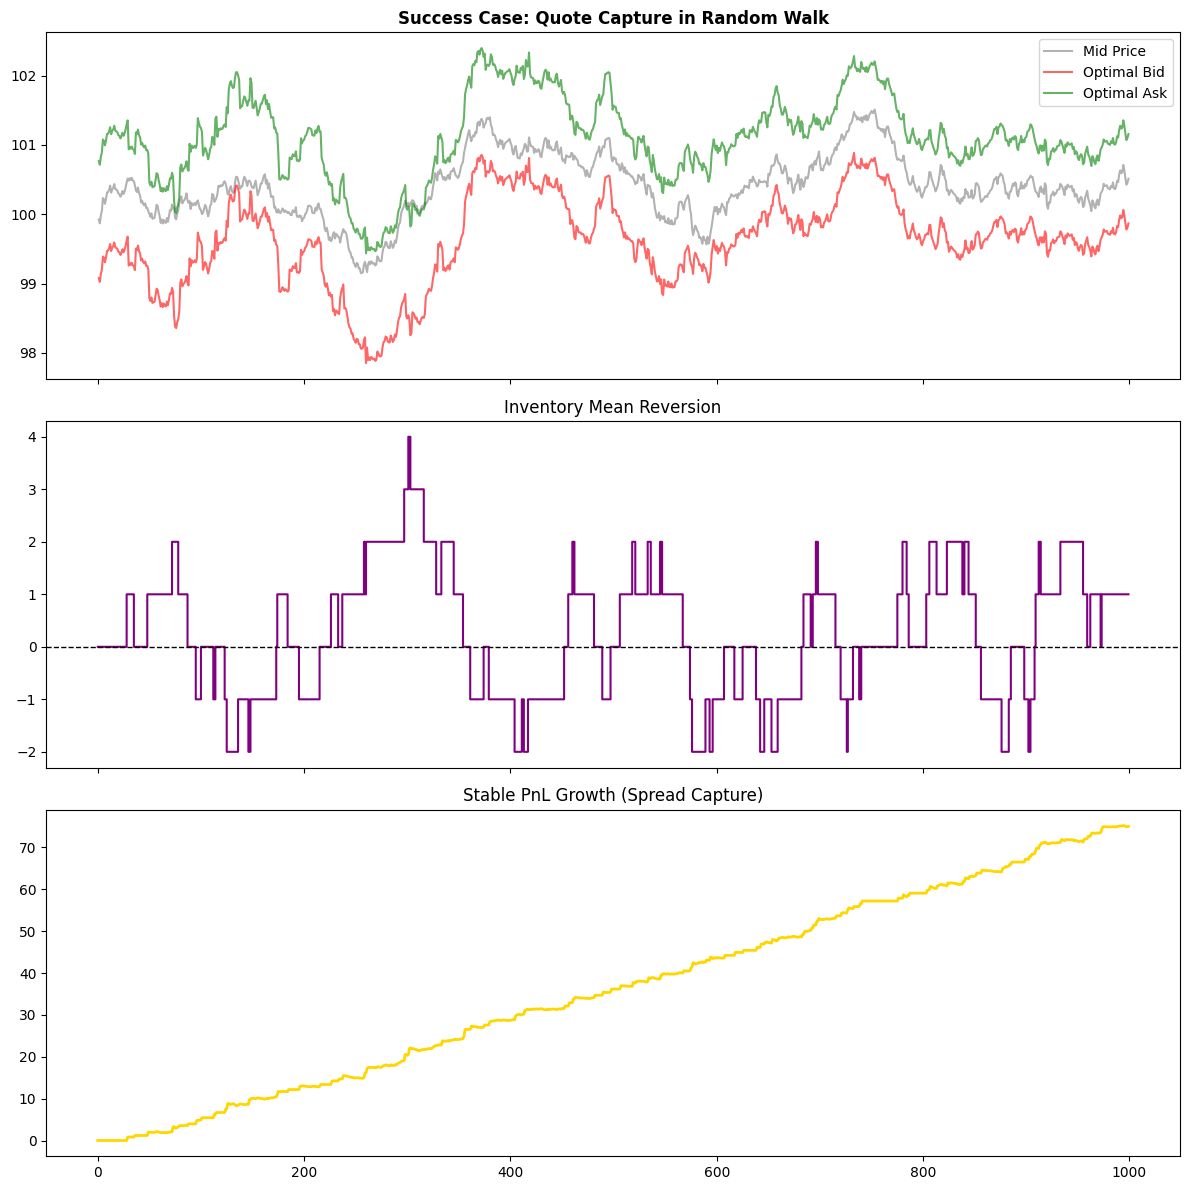

In [3]:
def run_perfect_scenario_sim(S0=100, T=1, steps=1000, gamma=0.1, k=1.5, A=140, sigma=2.0):
    """
    Simulates a 'Perfect Scenario' where mid-price is a pure random walk 
    and the AS engine successfully captures the spread.
    """
    dt = T / steps
    engine = AvellanedaStoikovEngine(gamma=gamma, k=k, A=A, sigma=sigma)
    
    # 1. Generate Pure Random Walk (No Drift)
    shocks = np.random.normal(0, sigma * np.sqrt(dt), steps)
    prices = S0 + np.cumsum(shocks)
    
    # 2. Initialize State
    inventory = np.zeros(steps)
    cash = np.zeros(steps)
    pnl = np.zeros(steps)
    bids, asks = np.zeros(steps), np.zeros(steps)

    # 3. Execution Loop
    for t in range(1, steps):
        s = prices[t]
        q = inventory[t-1]
        
        # Calculate optimal quotes for the current state
        # We normalize time to progress from 0 to T
        current_time = t * dt
        r = engine.calculate_reservation_price(s, q, current_time, T)
        spread = engine.calculate_optimal_spread(current_time, T)
        
        bid, ask = r - spread/2, r + spread/2
        bids[t], asks[t] = bid, ask

        # Calculate fill probabilities based on distance from mid
        prob_buy = engine.get_fill_probabilities(s - bid) * dt
        prob_sell = engine.get_fill_probabilities(ask - s) * dt
        
        # Simulate fills
        fill_buy = 1 if np.random.random() < prob_buy else 0
        fill_sell = 1 if np.random.random() < prob_sell else 0
        
        # Update Inventory and Cash
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        
        # Mark-to-Market PnL
        pnl[t] = cash[t] + (inventory[t] * s)

    return pd.DataFrame({
        "step": np.arange(steps),
        "mid": prices, "bid": bids, "ask": asks,
        "inventory": inventory, "pnl": pnl
    })

# Run and Visualize
df_perfect = run_perfect_scenario_sim()

fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
ax[0].plot(df_perfect['step'][1:], df_perfect['mid'][1:], label='Mid Price', color='black', alpha=0.3)
ax[0].plot(df_perfect['step'][1:], df_perfect['bid'][1:], label='Optimal Bid', color='red', alpha=0.6)
ax[0].plot(df_perfect['step'][1:], df_perfect['ask'][1:], label='Optimal Ask', color='green', alpha=0.6)
ax[0].set_title("Success Case: Quote Capture in Random Walk", fontweight='bold')
ax[0].legend()

ax[1].step(df_perfect['step'], df_perfect['inventory'], color='purple', label='Inventory (q)')
ax[1].axhline(0, color='black', lw=1, ls='--')
ax[1].set_title("Inventory Mean Reversion")

ax[2].plot(df_perfect['pnl'], color='gold', lw=2, label='Total PnL')
ax[2].set_title("Stable PnL Growth (Spread Capture)")
plt.tight_layout()
plt.show()

### Key Observations from the Success Case:
- **Inventory Management:** Notice how the inventory (purple) rarely deviates far from zero. The "shading" mechanism effectively attracts the opposite side of the trade as soon as a position is opened.
- **PnL Characteristics:** The PnL (gold) shows a steady, almost linear upward trend. This represents the "Spread Capture"—the strategy is successfully earning the bid-ask bounce while hedging out directional risk.
- **Market Microstructure:** The Poisson arrival process ensures that trades only occur when the mid-price touches or crosses our optimal quotes, validating the model's logic in a high-probability environment.

## 4. Market Entropy *and* Model Failures

While the Avellaneda-Stoikov model is a landmark in market microstructure, it relies on several assumptions that would fail in live markets. Here are three failure modes that the model could face.

1. <u>**Adverse Selection**</u>

   The model assumes that the mid-price is a driftless random walk-essentially a fair coin flip with no memory or direction. In reality, price discovery is driven by informed traders or institutional large orders that create persistent trends. The mechanism behind this fallback is that when a strong trend emerges, the model views your growing inventory as a risk to be "neutralized" by aggressively shading your quotes to attract the opposite side. You end up *selling the rally* or *"buying the dip"* repeatedly. By providing cheap liquidity to a market moving aggressively against you, the strategy accumulates an exploding position that never mean-reverts, leading to catastrophic drawdowns.
  
2. <u>**Volatility Clustering**</u> (Non-constant $\sigma$)

   Avellaneda-Stoikov treats volatility ($\sigma$) as a **static** input, assuming a constant market temperature throughout the session. However, real markets exhibit Volatility Clustering [2]—long periods of calm interrupted by sudden, violent jumps in variance. During a *flash crash* or a high-impact news event, the market's actual volatility may triple in seconds. Because the model remains calibrated to a stale, low-volatility regime, the spreads become dangerously narrow. As a result, the spread is tiny while the position is exposed to massive, unpriced tail risk.
   
3. <u>**Execution Latency & Adverse Fills**</u>

   Finally, the model assumes that trades are independent, random events (Poisson arrivals) and that order placement is instantaneous. However, in high-frequency environments, a fill is rarely random; it is often an adverse signal. Specifically, if the quote is hit, it is frequently by another predatory algorithm that has already processed a price move on another exchange before the quote could be updated (Latency). The model assumes the price will bounce off the quote and subsequently capture the spread. In reality, the market often moves through the price. By the time the fill is confirmed, the mid-price has already shifted past the execution point, resulting in an immediate realized loss before hedging can occur.

### 4.1. Adverse Selection Simulation

Total fills: 233
Final inventory: -10.0
Final PnL: -1865.4891541774145


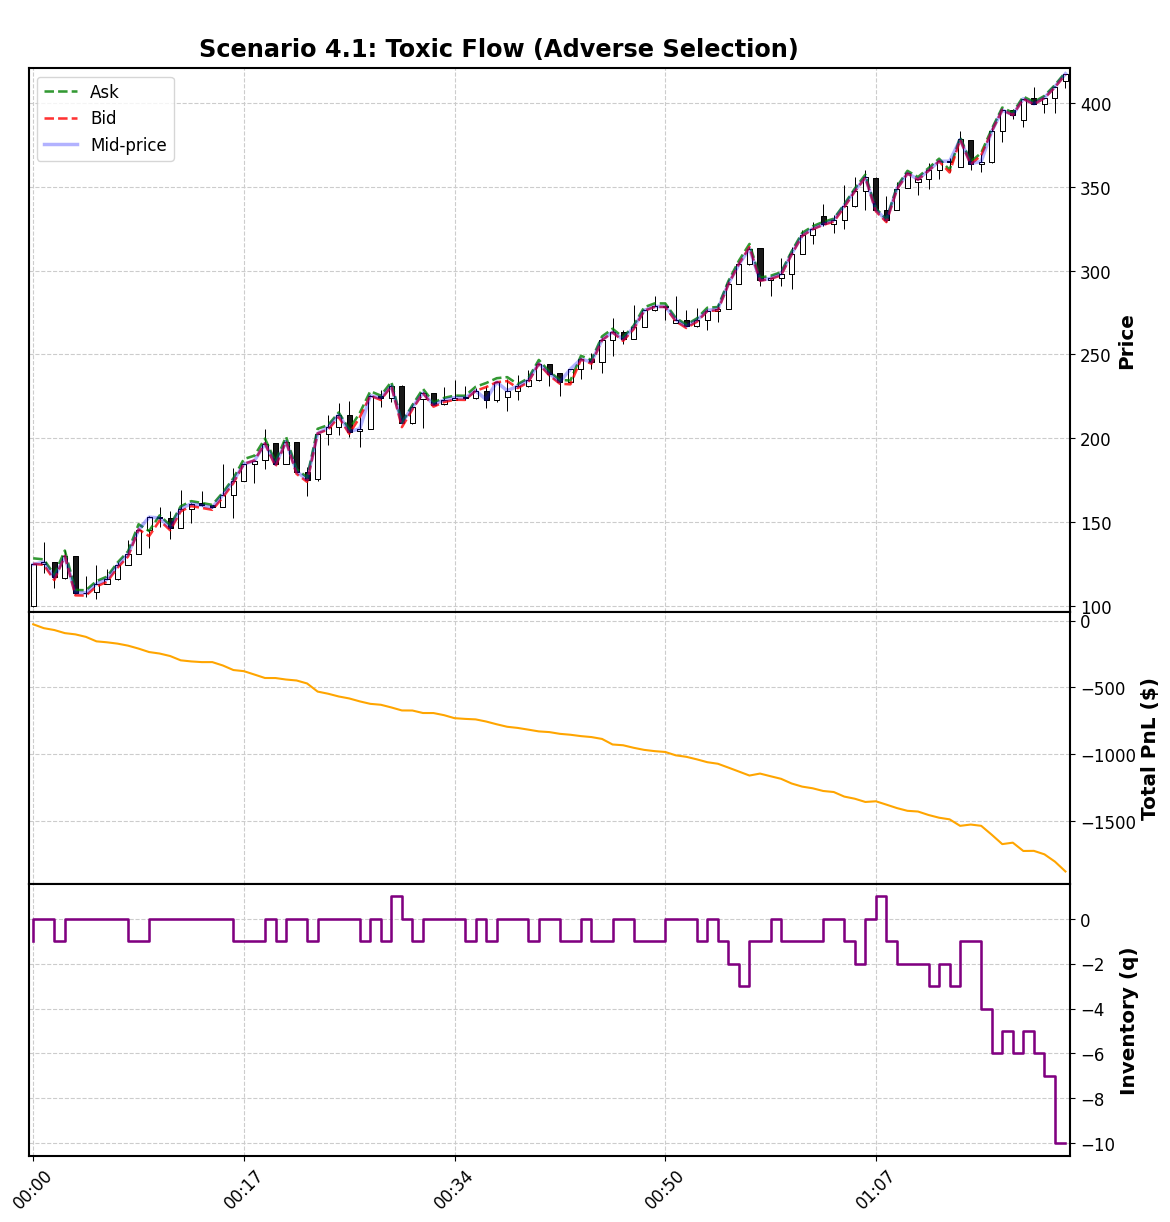

In [4]:
import mplfinance as mpf

def simulate_toxic_flow(S0=100, T=5, steps=5000, drift=0.015):
    dt = T / steps
    engine = AvellanedaStoikovEngine(gamma=0.1, k=1.5, A=140, sigma=2.0)

    # Initialize simulation arrays and stochastic components
    shocks = np.random.normal(0, 4.0 * np.sqrt(dt), steps)
    prices = np.zeros(steps); prices[0] = S0
    inventory, cash, pnl = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    bids, asks, fills_sell = np.zeros(steps), np.zeros(steps), [np.nan] * steps
    
    for t in range(1, steps):
        shock = shocks[t]
        
        # Update mid-price based on current drift and random shock
        prices[t] = prices[t - 1] + shock + drift * dt

        # Calculate optimal quotes based on the Avellaneda-Stoikov framework
        s, q, curr_t = prices[t], inventory[t-1], t * dt
        r      = engine.calculate_reservation_price(s, q, curr_t, T)
        spread = engine.calculate_optimal_spread(curr_t, T)
        bid, ask = r - spread/2, r + spread/2
    
        bids[t] = bid
        asks[t] = ask

        # Determine fill probabilities with an asymmetric skew (Toxic Flow)
        prob_sell = min(1.0, engine.get_fill_probabilities(max(0, ask - s)) * 2.5 * dt)
        prob_buy  = min(1.0, engine.get_fill_probabilities(max(0, s - bid)) * 0.7 * dt)

        # Execute trades using a single random draw for mutually exclusive fills
        u = np.random.random()
        fill_sell = int(u < prob_sell)
        fill_buy  = int((u >= prob_sell) and (u < prob_sell + prob_buy))
    
        # MODELING ADVERSE SELECTION:
        # Trades cause immediate price impact and trend persistence
        price_impact = np.random.normal(3 * spread, spread)
        trend_strength = 0.2
        
        if fill_sell:
            fills_sell[t] = ask
            prices[t] = ask + price_impact # Price moves against the MM after selling
            drift += trend_strength # Informed buying creates upward momentum
            
        if fill_buy:
            prices[t] = bid - price_impact
            drift -= trend_strength 
            
        drift = np.clip(drift, -1.0, 1.0)
        
        # Update accounting: Inventory, Cash, and Mark-to-Market PnL
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        pnl[t] = cash[t] + inventory[t] * prices[t]

    print("Total fills:", np.sum(~np.isnan(fills_sell)))
    print("Final inventory:", inventory[-1])
    print("Final PnL:", pnl[-1])
    
    return pd.DataFrame({
        "step": np.arange(steps), "mid": prices, "bid": bids, "ask": asks, 
        "inventory": inventory, "pnl": pnl, "fills_sell": fills_sell
    })

# Run simulation and resample data into OHLC candles for visualization
df_toxic = simulate_toxic_flow()

window = 50

ohlc = pd.DataFrame()

ohlc['Open']       = df_toxic['mid'].shift(window-1).iloc[::window]
ohlc['High']       = df_toxic['mid'].rolling(window).max().iloc[::window]
ohlc['Low']        = df_toxic['mid'].rolling(window).min().iloc[::window]
ohlc['Close']      = df_toxic['mid'].iloc[::window]
ohlc['pnl']        = df_toxic['pnl'].iloc[::window]
ohlc['inventory']  = df_toxic['inventory'].iloc[::window]
ohlc['bid']        = df_toxic['bid'].iloc[::window]
ohlc['ask']        = df_toxic['ask'].iloc[::window]
ohlc['fills_sell'] = df_toxic['fills_sell'].rolling(window).max().iloc[::window]
ohlc['step']       = df_toxic['step'].iloc[::window]

ohlc = ohlc.dropna(subset=['Open', 'High', 'Low', 'Close'])

ohlc.index = pd.to_datetime(ohlc['step'], unit='s')

apds = [
    mpf.make_addplot(ohlc['ask'], label="Ask", color='green', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['bid'], label="Bid", color='red', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['Close'], label="Mid-price", color='blue', alpha=0.3, width=2.5),
    mpf.make_addplot(ohlc['pnl'], panel=1, color='orange', ylabel='Total PnL ($)', width=1.5),
    mpf.make_addplot(ohlc['inventory'], panel=2, color='purple', ylabel='Inventory (q)', type='step')
]

if not ohlc['fills_sell'].dropna().empty:
    apds.append(mpf.make_addplot(ohlc['fills_sell'], type='scatter', markersize=60, marker='v', color='darkred'))

mpf.plot(ohlc, type='candle', style='classic', addplot=apds, 
         title="\nScenario 4.1: Toxic Flow (Adverse Selection)",
         figsize=(12, 14), 
         panel_ratios=(4, 2, 2),
         scale_padding={'top': 4},
         tight_layout=True)

#### Summary of Simulation Technique and Visualization

**The simulation logic**

- <u>Asymmetric Fill</u>: The core failure is triggered by the fill probabilities. We use $\min(1.0, \text{Prob(fill)} \times \text{Multiplier} \times dt)$ to ensure that during an uptrend, the probability of being hit on the Ask is significantly higher (2.5x) than being hit on the Bid (0.7x). This creates a directional trap for the Market Maker. Unlike the standard Poisson process, which assumes buy and sell orders arrive independently and balance out over time, here, buyers are aggressive because they possess superior information, effectively 'trapping' the MM into selling a fundamentally underpriced asset. The result is a total failure of the model's inventory rebalancing logic, as the MM accumulates a losing position that the reservation price cannot correct.

- <u>The Adverse Selection Feedback Loop</u>: We manually override the price process after each trade to simulate Informed Momentum, where every *Sell* order (MM selling to an informed buyer)
  - Triggers an immediate $\text{Normal}(3 \times spread, spread)$ price jump. This ensures the Market Maker cannot "buy back" the position at a profit.
  - Increments the `drift` parameter, simulating a market where a single informed trade predicts a persistent sequence of future price increases. The `np.clip(drift, -1.0, 1.0)` we maintain a "sane reality" that prevents the price from reaching infinity while ensuring the trend remains relentless enough to overwhelm the model's mean-reversion logic.

**Visualization Components**

- <u>Manual OHLC Vectorization</u>: Instead of using standard `Pandas.resample()`, which can introduce interpolation artifacts or "time-leaks," we utilize a vectorized slicing approach with `iloc[::window]` and `rolling(window)`. This ensures that the risk metrics—specifically **PnL** and **Inventory**—are captured at the exact terminal state of each candle. This precision is critical for demonstrating Adverse Selection; it prevents "visual desync" where the PnL collapse appears to lag behind the price spikes that caused it.

### 4.2. Volatility Clustering Simulation

Total fills: 741
Final inventory: 3.0
Final PnL: -19715.4596983073


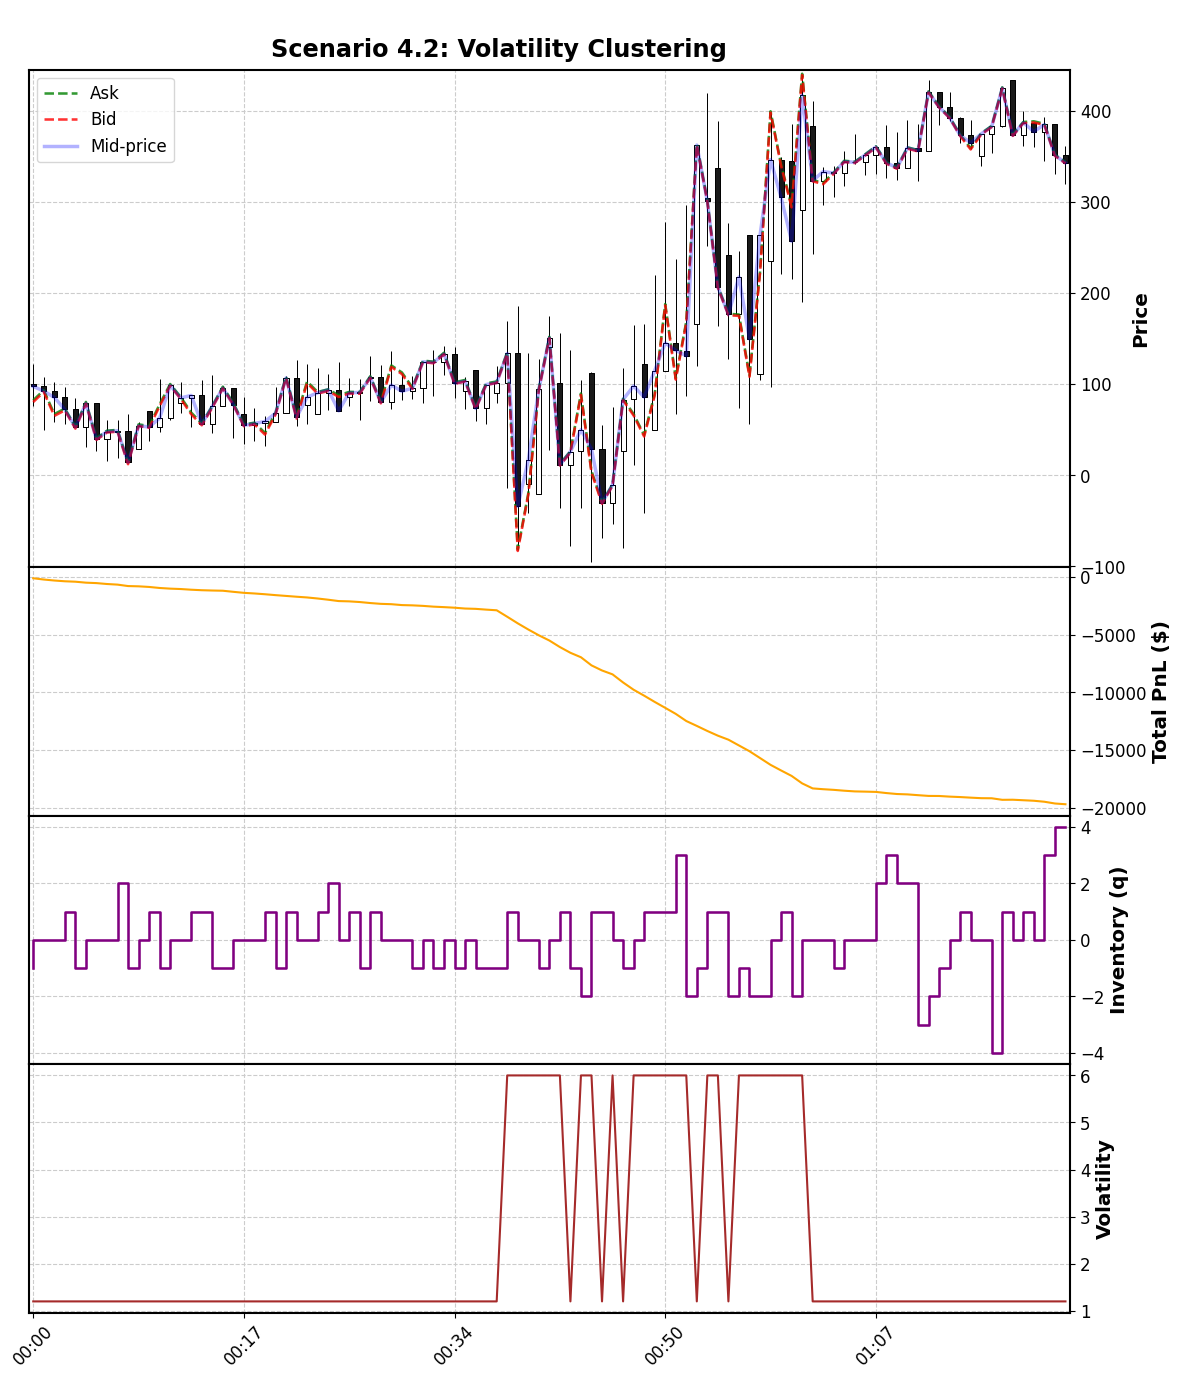

In [11]:
def simulate_volatility_clustering(S0=100, T=5, steps=5000):
    dt = T / steps
    
    # AS engine still assumes LOW volatility
    engine = AvellanedaStoikovEngine(
        gamma=0.1,
        k=1.5,
        A=140,
        sigma=1.2      # stale volatility estimate
    )

    # True market volatility regimes
    sigma_low  = 1.2
    sigma_high = 6.0

    crash_start = int(steps * 0.45)
    crash_end   = int(steps * 0.75)

    prices = np.zeros(steps)
    prices[0] = S0

    inventory = np.zeros(steps)
    cash = np.zeros(steps)
    pnl = np.zeros(steps)

    bids = np.zeros(steps)
    asks = np.zeros(steps)

    fills_sell = [np.nan] * steps
    volatility = np.zeros(steps)

    drift = 0.0

    for t in range(1, steps):
        # -------- VOLATILITY REGIME --------
        if crash_start < t < crash_end:
            # persistent clustered volatility
            if np.random.random() < 0.85:
                sigma = sigma_high
            else:
                sigma = sigma_low
        else:
            sigma = sigma_low

        volatility[t] = sigma
        shock = np.random.normal(0, sigma * np.sqrt(dt))
        prices[t] = prices[t-1] + shock + drift * dt

        # -------- AVELLANEDA-STOIKOV QUOTES --------
        s = prices[t]
        q = inventory[t-1]
        curr_t = t * dt

        r = engine.calculate_reservation_price(s, q, curr_t, T)
        spread = engine.calculate_optimal_spread(curr_t, T)

        bid = r - spread/2
        ask = r + spread/2

        bids[t] = bid
        asks[t] = ask

        # -------- HIGH VOLATILITY = MORE FILLS --------
        vol_multiplier = 1 + (sigma / sigma_low)

        prob_sell = min(
            1.0,
            engine.get_fill_probabilities(max(0, ask - s)) * vol_multiplier * dt
        )
        prob_buy = min(
            1.0,
            engine.get_fill_probabilities(max(0, s - bid)) * vol_multiplier * dt
        )

        u = np.random.random()

        fill_sell = int(u < prob_sell)
        fill_buy  = int((u >= prob_sell) and (u < prob_sell + prob_buy))

        # -------- ADVERSE PRICE MOVES --------
        price_impact = np.random.normal(
            4 * spread * vol_multiplier,
            spread * vol_multiplier
        )

        if fill_sell:
            fills_sell[t] = ask
            prices[t] = ask + price_impact
            drift += 0.4

        if fill_buy:
            prices[t] = bid - price_impact
            drift -= 0.4

        drift = np.clip(drift, -2.0, 2.0)

        # -------- ACCOUNTING --------
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        pnl[t] = cash[t] + inventory[t] * prices[t]

    print("Total fills:", np.sum(~np.isnan(fills_sell)))
    print("Final inventory:", inventory[-1])
    print("Final PnL:", pnl[-1])

    return pd.DataFrame({
        "step": np.arange(steps),
        "mid": prices,
        "bid": bids,
        "ask": asks,
        "inventory": inventory,
        "pnl": pnl,
        "fills_sell": fills_sell,
        "volatility": volatility
    })

df_vol = simulate_volatility_clustering()

# Resample for OHLC candles
window = 50
ohlc = pd.DataFrame()
ohlc['Open']       = df_vol['mid'].shift(window-1).iloc[::window]
ohlc['High']       = df_vol['mid'].rolling(window).max().iloc[::window]
ohlc['Low']        = df_vol['mid'].rolling(window).min().iloc[::window]
ohlc['Close']      = df_vol['mid'].iloc[::window]
ohlc['pnl']        = df_vol['pnl'].iloc[::window]
ohlc['inventory']  = df_vol['inventory'].iloc[::window]
ohlc['bid']        = df_vol['bid'].iloc[::window]
ohlc['ask']        = df_vol['ask'].iloc[::window]
ohlc['volatility'] = df_vol['volatility'].iloc[::window]
ohlc['fills_sell'] = df_vol['fills_sell'].rolling(window).max().iloc[::window]
ohlc['step']       = df_vol['step'].iloc[::window]

ohlc = ohlc.dropna(subset=['Open', 'High', 'Low', 'Close'])
ohlc.index = pd.to_datetime(ohlc['step'], unit='s')

# Plot
apds = [
    mpf.make_addplot(ohlc['ask'], label="Ask", color='green', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['bid'], label="Bid", color='red', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['Close'], label="Mid-price", color='blue', alpha=0.3, width=2.5),
    mpf.make_addplot(ohlc['pnl'], panel=1, color='orange', ylabel='Total PnL ($)', width=1.5),
    mpf.make_addplot(ohlc['inventory'], panel=2, color='purple', ylabel='Inventory (q)', type='step'),
    mpf.make_addplot(ohlc['volatility'], panel=3, color='brown', ylabel='Volatility', width=1.5)
]

if not ohlc['fills_sell'].dropna().empty:
    apds.append(mpf.make_addplot(ohlc['fills_sell'], type='scatter', markersize=60, marker='v', color='darkred'))

mpf.plot(ohlc, type='candle', style='classic', addplot=apds,
         title="\nScenario 4.2: Volatility Clustering",
         figsize=(12, 16),
         panel_ratios=(4, 2, 2, 2),
         scale_padding={'top': 4},
         tight_layout=True)

In [ ]:
### S

### 4.3. Execution Latency and Adverse Fills

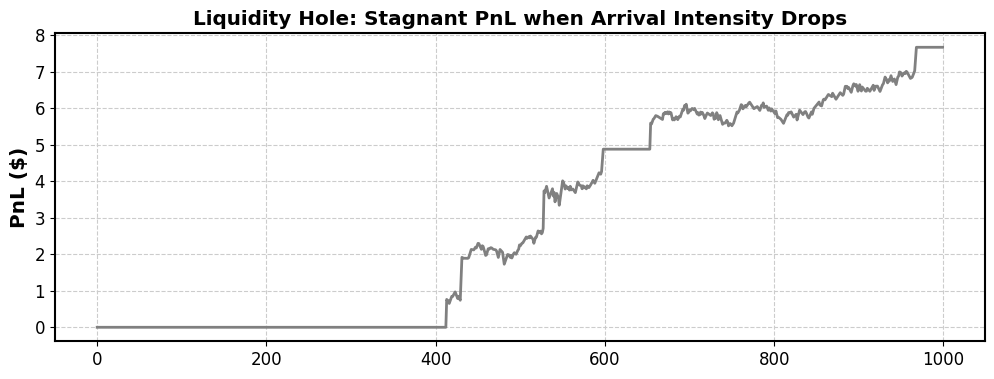

In [8]:
def simulate_liquidity_hole(S0=100, T=1, steps=1000):
    dt = T / steps
    # MM assumes high liquidity (A=140)
    engine = AvellanedaStoikovEngine(gamma=0.1, k=1.5, A=140, sigma=2.0) 
    
    prices = S0 + np.cumsum(np.random.normal(0, 2.0 * np.sqrt(dt), steps))
    inventory, cash, pnl = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    
    for t in range(1, steps):
        s, q, curr_t = prices[t], inventory[t-1], t * dt
        r = engine.calculate_reservation_price(s, q, curr_t, T)
        spread = engine.calculate_optimal_spread(curr_t, T)
        bid, ask = r - spread/2, r + spread/2
        
        # MARKET REALITY: Intensity 'A' is actually 10.0 (Liquidity Hole)
        actual_prob_buy = (10.0 * np.exp(-1.5 * (s - bid))) * dt
        actual_prob_sell = (10.0 * np.exp(-1.5 * (ask - s))) * dt
        
        fill_buy = 1 if np.random.random() < actual_prob_buy else 0
        fill_sell = 1 if np.random.random() < actual_prob_sell else 0
        
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        pnl[t] = cash[t] + (inventory[t] * s)
    
    return pd.DataFrame({"step": np.arange(steps), "pnl": pnl})

df_hole = simulate_liquidity_hole()

# Visualization
plt.figure(figsize=(12, 4))
plt.plot(df_hole['pnl'], color='gray', label='Strategy PnL')
plt.title("Liquidity Hole: Stagnant PnL when Arrival Intensity Drops", fontweight='bold')
plt.ylabel("PnL ($)")
plt.show()

## 5. Model Reiteration and Open Questions

## 6. References
<a id="references"></a>
[1] - https://people.orie.cornell.edu/sfs33/LimitOrderBook.pdf

## Appendix: Performance Benchmarks